# HW08-09: PyTorch MLP — регуляризация и оптимизация обучения

**Датасет:** EMNIST Balanced (Вариант B) — 47 классов (цифры + буквы), 28×28, grayscale

**Часть A (S08):** MLP и регуляризация (Dropout, BatchNorm, EarlyStopping) — эксперименты E1-E4  
**Часть B (S09):** LR диагностика, Adam vs SGD+momentum, weight decay — эксперименты O1-O3

## 1. Импорты, seed и устройство

In [1]:
import os
import json
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

# --- Воспроизводимость ---
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# --- Устройство ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python:      {__import__('sys').version}")
print(f"torch:       {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"device:      {device}")

Python:      3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch:       2.10.0+cu128
torchvision: 0.25.0+cu128
device:      cuda


In [2]:
# Создание директорий для артефактов (нужно на Colab)
os.makedirs("artifacts/figures", exist_ok=True)

## 2. Данные и DataLoader

Датасет: **EMNIST Balanced** — 47 классов (10 цифр + 26 букв + 11 дополнительных символов), 28×28, grayscale.

- Train/Val split: 80/20 от train-части (фиксированный seed)
- Test: стандартный из torchvision (используется один раз в конце)

In [3]:
# Трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Загрузка датасета
train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

NUM_CLASSES = len(set(train_full.targets.numpy()))

print(f"Train full size: {len(train_full)}")
print(f"Test size:       {len(test_ds)}")
print(f"Num classes:     {NUM_CLASSES}")

100%|██████████| 562M/562M [00:03<00:00, 175MB/s]


Train full size: 112800
Test size:       18800
Num classes:     47


In [4]:
# Train/Val split (80/20)
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

print(f"Train size: {len(train_ds)}")
print(f"Val size:   {len(val_ds)}")

# DataLoader
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
)

# Sanity-check
x_batch, y_batch = next(iter(train_loader))
print(f"\nx_batch shape: {x_batch.shape}, dtype: {x_batch.dtype}")
print(f"y_batch shape: {y_batch.shape}, dtype: {y_batch.dtype}")
print(f"x range: [{x_batch.min():.2f}, {x_batch.max():.2f}]")

Train size: 90240
Val size:   22560

x_batch shape: torch.Size([256, 1, 28, 28]), dtype: torch.float32
y_batch shape: torch.Size([256]), dtype: torch.int64
x range: [-1.00, 1.00]


## 3. Модель MLP и цикл обучения

In [5]:
class MLP(nn.Module):
    """
    MLP с опциональным Dropout и BatchNorm.
    Порядок слоёв: Linear -> [BatchNorm] -> Activation -> [Dropout]
    """
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (512, 256),
        num_classes: int = 47,
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Sanity-check
_model = MLP(num_classes=NUM_CLASSES).to(device)
with torch.no_grad():
    _out = _model(x_batch.to(device))
print(f"Model output shape: {_out.shape}")
print(f"Total params: {sum(p.numel() for p in _model.parameters()):,}")
del _model, _out

Model output shape: torch.Size([256, 47])
Total params: 545,327


In [6]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [7]:
class EarlyStopping:
    """Ранняя остановка по val_accuracy (чем больше, тем лучше)."""
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [8]:
def fit(
    model, train_loader, val_loader, optimizer, criterion, device,
    epochs: int = 20, early_stopping=None, verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"  epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f} acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            if early_stopping.step(va_acc, model):
                if verbose:
                    print(
                        f"  EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history


def plot_history(history: dict, title: str = "", save_path: str = None):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="train_loss")
    ax1.plot(epochs, history["val_loss"], label="val_loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax1.set_title(f"{title} — Loss" if title else "Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], label="train_acc")
    ax2.plot(epochs, history["val_acc"], label="val_acc")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")
    ax2.set_title(f"{title} — Accuracy" if title else "Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()

## 4. Часть A: регуляризация и переобучение (E1–E4)

Все эксперименты используют одинаковые настройки (split, batch_size, epochs=20, Adam lr=1e-3), чтобы сравнение было корректным.

| ID | Описание |
|----|----------|
| E1 | Base MLP (512, 256), без Dropout/BatchNorm |
| E2 | + Dropout(p=0.3) |
| E3 | + BatchNorm |
| E4 | Лучший из E2/E3 + EarlyStopping(patience=5), до 50 эпох |

In [9]:
# Общие параметры для части A
HIDDEN_DIMS = (512, 256)
LR_BASE = 1e-3
EPOCHS_A = 20

# Словарь для хранения результатов всех экспериментов
all_results = {}
all_histories = {}

### E1: Base MLP (без Dropout, без BatchNorm)

=== E1: Base MLP ===
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=47, bias=True)
  )
)
  epoch 01/20 | train loss=1.2852 acc=0.6321 | val loss=0.8442 acc=0.7437
  epoch 02/20 | train loss=0.6944 acc=0.7802 | val loss=0.6321 acc=0.8004
  epoch 03/20 | train loss=0.5566 acc=0.8182 | val loss=0.5579 acc=0.8209
  epoch 04/20 | train loss=0.4898 acc=0.8352 | val loss=0.5201 acc=0.8304
  epoch 05/20 | train loss=0.4435 acc=0.8474 | val loss=0.5144 acc=0.8267
  epoch 06/20 | train loss=0.4118 acc=0.8567 | val loss=0.4966 acc=0.8367
  epoch 07/20 | train loss=0.3824 acc=0.8639 | val loss=0.4852 acc=0.8388
  epoch 08/20 | train loss=0.3591 acc=0.8702 | val loss=0.4738 acc=0.8451
  epoch 09/20 | train loss=0.3387 acc=0.8764 | val loss=0.4894 acc=0.8403
  epoch 10/20 | train 

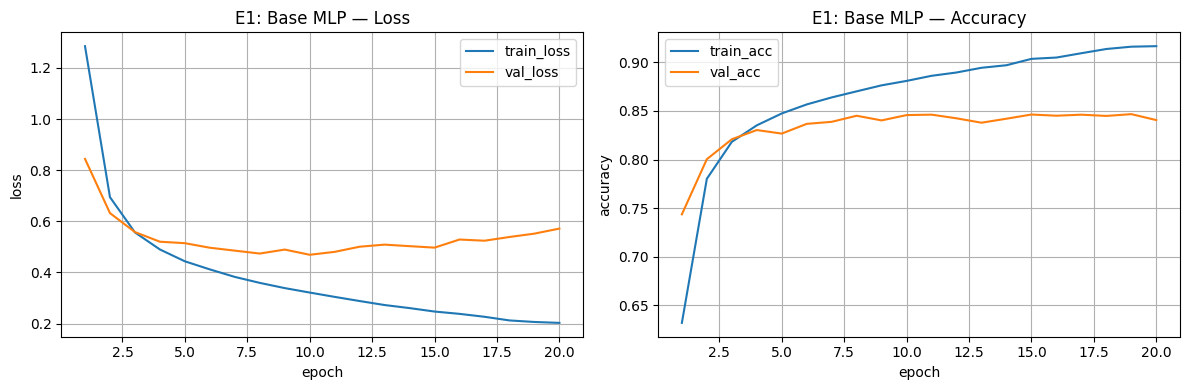

In [10]:
set_seed(SEED)
model_e1 = MLP(hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=0.0, use_batchnorm=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=LR_BASE)
criterion = nn.CrossEntropyLoss()

print("=== E1: Base MLP ===")
print(model_e1)
history_e1 = fit(model_e1, train_loader, val_loader, optimizer_e1, criterion, device, epochs=EPOCHS_A)
plot_history(history_e1, title="E1: Base MLP")

all_histories["E1"] = history_e1
all_results["E1"] = {
    "best_val_accuracy": max(history_e1["val_acc"]),
    "best_val_loss": min(history_e1["val_loss"]),
    "epochs_trained": len(history_e1["train_loss"]),
}

### E2: MLP + Dropout(p=0.3)

=== E2: MLP + Dropout(0.3) ===
  epoch 01/20 | train loss=1.5202 acc=0.5631 | val loss=0.8611 acc=0.7392
  epoch 02/20 | train loss=0.8965 acc=0.7220 | val loss=0.6761 acc=0.7871
  epoch 03/20 | train loss=0.7651 acc=0.7568 | val loss=0.6055 acc=0.8076
  epoch 04/20 | train loss=0.6974 acc=0.7743 | val loss=0.5542 acc=0.8214
  epoch 05/20 | train loss=0.6498 acc=0.7862 | val loss=0.5277 acc=0.8257
  epoch 06/20 | train loss=0.6157 acc=0.7969 | val loss=0.5137 acc=0.8296
  epoch 07/20 | train loss=0.5987 acc=0.8011 | val loss=0.4891 acc=0.8386
  epoch 08/20 | train loss=0.5732 acc=0.8073 | val loss=0.4765 acc=0.8385
  epoch 09/20 | train loss=0.5538 acc=0.8129 | val loss=0.4670 acc=0.8448
  epoch 10/20 | train loss=0.5419 acc=0.8138 | val loss=0.4638 acc=0.8445
  epoch 11/20 | train loss=0.5320 acc=0.8184 | val loss=0.4574 acc=0.8458
  epoch 12/20 | train loss=0.5204 acc=0.8209 | val loss=0.4642 acc=0.8431
  epoch 13/20 | train loss=0.5097 acc=0.8234 | val loss=0.4546 acc=0.8486
  epoch

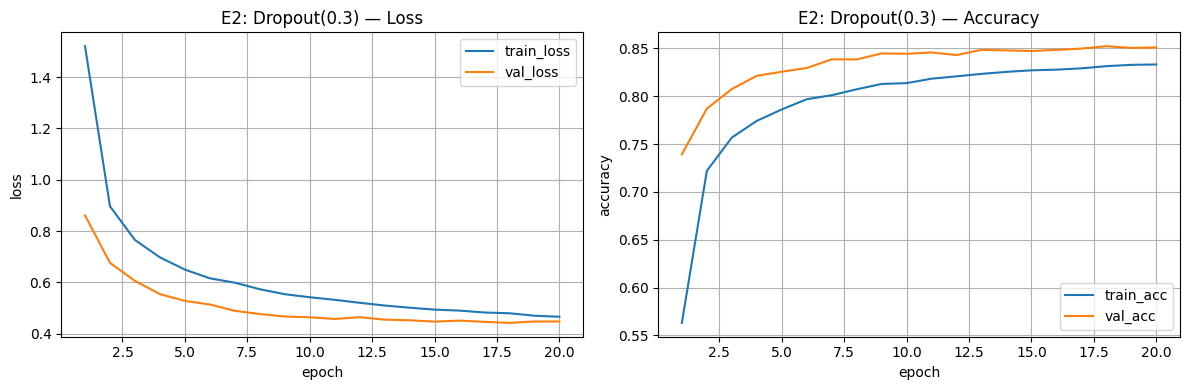

In [11]:
set_seed(SEED)
model_e2 = MLP(hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=0.3, use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=LR_BASE)

print("=== E2: MLP + Dropout(0.3) ===")
history_e2 = fit(model_e2, train_loader, val_loader, optimizer_e2, criterion, device, epochs=EPOCHS_A)
plot_history(history_e2, title="E2: Dropout(0.3)")

all_histories["E2"] = history_e2
all_results["E2"] = {
    "best_val_accuracy": max(history_e2["val_acc"]),
    "best_val_loss": min(history_e2["val_loss"]),
    "epochs_trained": len(history_e2["train_loss"]),
}

### E3: MLP + BatchNorm

=== E3: MLP + BatchNorm ===
  epoch 01/20 | train loss=0.9289 acc=0.7415 | val loss=0.6032 acc=0.8106
  epoch 02/20 | train loss=0.4928 acc=0.8358 | val loss=0.5180 acc=0.8266
  epoch 03/20 | train loss=0.4087 acc=0.8583 | val loss=0.4665 acc=0.8420
  epoch 04/20 | train loss=0.3578 acc=0.8711 | val loss=0.4733 acc=0.8428
  epoch 05/20 | train loss=0.3207 acc=0.8829 | val loss=0.4566 acc=0.8447
  epoch 06/20 | train loss=0.2900 acc=0.8917 | val loss=0.4616 acc=0.8470
  epoch 07/20 | train loss=0.2647 acc=0.8990 | val loss=0.4632 acc=0.8515
  epoch 08/20 | train loss=0.2441 acc=0.9063 | val loss=0.4679 acc=0.8450
  epoch 09/20 | train loss=0.2252 acc=0.9123 | val loss=0.4715 acc=0.8522
  epoch 10/20 | train loss=0.2125 acc=0.9162 | val loss=0.4908 acc=0.8458
  epoch 11/20 | train loss=0.1977 acc=0.9220 | val loss=0.4953 acc=0.8467
  epoch 12/20 | train loss=0.1840 acc=0.9267 | val loss=0.5170 acc=0.8411
  epoch 13/20 | train loss=0.1721 acc=0.9299 | val loss=0.5230 acc=0.8455
  epoch 14

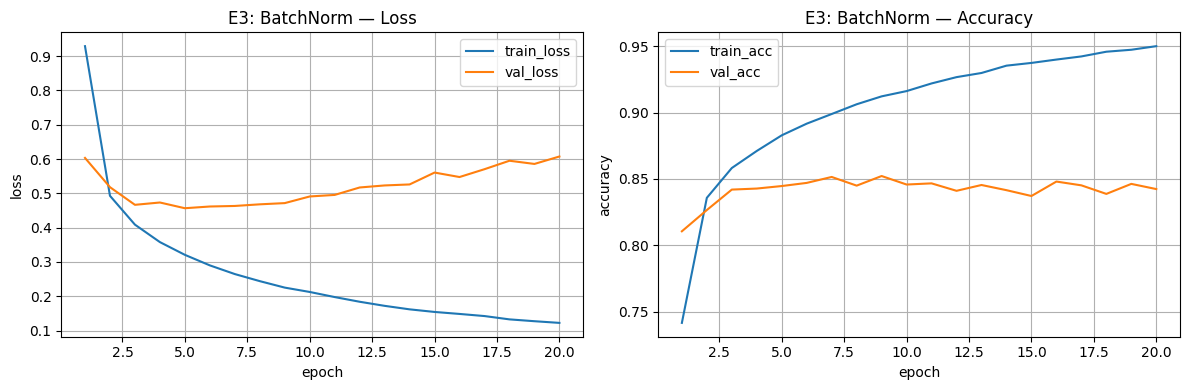

In [12]:
set_seed(SEED)
model_e3 = MLP(hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=0.0, use_batchnorm=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=LR_BASE)

print("=== E3: MLP + BatchNorm ===")
history_e3 = fit(model_e3, train_loader, val_loader, optimizer_e3, criterion, device, epochs=EPOCHS_A)
plot_history(history_e3, title="E3: BatchNorm")

all_histories["E3"] = history_e3
all_results["E3"] = {
    "best_val_accuracy": max(history_e3["val_acc"]),
    "best_val_loss": min(history_e3["val_loss"]),
    "epochs_trained": len(history_e3["train_loss"]),
}

### Выбор лучшего из E2/E3

In [13]:
# Сравнение E2 vs E3 по лучшему val_accuracy
e2_best = all_results["E2"]["best_val_accuracy"]
e3_best = all_results["E3"]["best_val_accuracy"]

print(f"E2 best val_acc: {e2_best:.4f}")
print(f"E3 best val_acc: {e3_best:.4f}")

if e2_best >= e3_best:
    best_reg = "E2"
    best_dropout_p = 0.3
    best_use_bn = False
    print("-> Лучший: E2 (Dropout)")
else:
    best_reg = "E3"
    best_dropout_p = 0.0
    best_use_bn = True
    print("-> Лучший: E3 (BatchNorm)")

print(f"\nE4 будет использовать конфигурацию {best_reg} + EarlyStopping")

E2 best val_acc: 0.8524
E3 best val_acc: 0.8522
-> Лучший: E2 (Dropout)

E4 будет использовать конфигурацию E2 + EarlyStopping


### E4: Лучший из E2/E3 + EarlyStopping (patience=5)

Это **лучшая модель домашки**. Из неё сохраняется `best_model.pt`.

=== E4: E2 config + EarlyStopping(patience=5) ===
  epoch 01/50 | train loss=1.5202 acc=0.5631 | val loss=0.8611 acc=0.7392
  epoch 02/50 | train loss=0.8965 acc=0.7220 | val loss=0.6761 acc=0.7871
  epoch 03/50 | train loss=0.7651 acc=0.7568 | val loss=0.6055 acc=0.8076
  epoch 04/50 | train loss=0.6974 acc=0.7743 | val loss=0.5542 acc=0.8214
  epoch 05/50 | train loss=0.6498 acc=0.7862 | val loss=0.5277 acc=0.8257
  epoch 06/50 | train loss=0.6157 acc=0.7969 | val loss=0.5137 acc=0.8296
  epoch 07/50 | train loss=0.5987 acc=0.8011 | val loss=0.4891 acc=0.8386
  epoch 08/50 | train loss=0.5732 acc=0.8073 | val loss=0.4765 acc=0.8385
  epoch 09/50 | train loss=0.5538 acc=0.8129 | val loss=0.4670 acc=0.8448
  epoch 10/50 | train loss=0.5419 acc=0.8138 | val loss=0.4638 acc=0.8445
  epoch 11/50 | train loss=0.5320 acc=0.8184 | val loss=0.4574 acc=0.8458
  epoch 12/50 | train loss=0.5204 acc=0.8209 | val loss=0.4642 acc=0.8431
  epoch 13/50 | train loss=0.5097 acc=0.8234 | val loss=0.4546

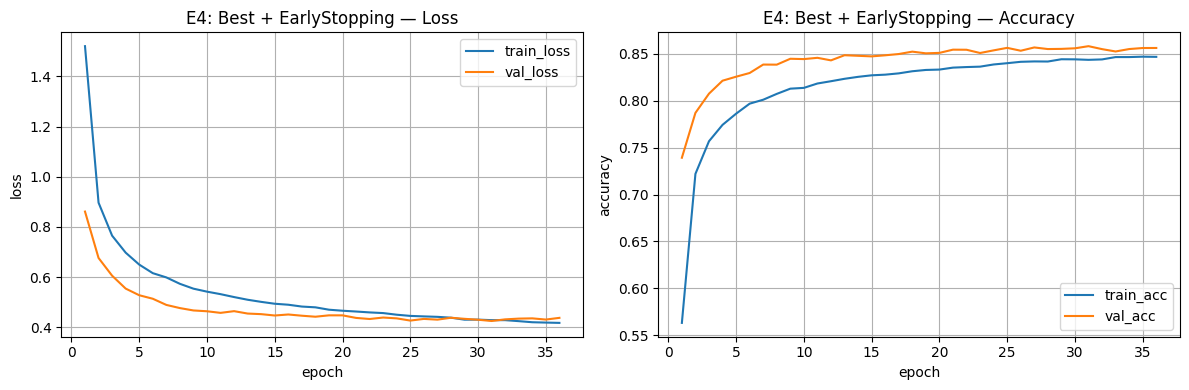

In [14]:
set_seed(SEED)
model_e4 = MLP(
    hidden_dims=HIDDEN_DIMS,
    num_classes=NUM_CLASSES,
    dropout_p=best_dropout_p,
    use_batchnorm=best_use_bn,
).to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=LR_BASE)
es = EarlyStopping(patience=5)

print(f"=== E4: {best_reg} config + EarlyStopping(patience=5) ===")
history_e4 = fit(
    model_e4, train_loader, val_loader, optimizer_e4, criterion, device,
    epochs=50, early_stopping=es,
)
plot_history(history_e4, title="E4: Best + EarlyStopping",
             save_path="artifacts/figures/curves_best.png")

all_histories["E4"] = history_e4
all_results["E4"] = {
    "best_val_accuracy": max(history_e4["val_acc"]),
    "best_val_loss": min(history_e4["val_loss"]),
    "epochs_trained": len(history_e4["train_loss"]),
}

### Сохранение лучшей модели (E4) и конфига

In [15]:
# Сохранение state_dict лучшей модели
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")
print("Saved: artifacts/best_model.pt")

# Сохранение конфига
best_config = {
    "experiment_id": "E4",
    "based_on": best_reg,
    "dataset": "EMNIST_balanced",
    "seed": SEED,
    "input_dim": 28 * 28,
    "hidden_dims": list(HIDDEN_DIMS),
    "num_classes": NUM_CLASSES,
    "activation": "ReLU",
    "dropout_p": best_dropout_p,
    "use_batchnorm": best_use_bn,
    "optimizer": "Adam",
    "lr": LR_BASE,
    "batch_size": BATCH_SIZE,
    "early_stopping_patience": 5,
    "epochs_trained": all_results["E4"]["epochs_trained"],
    "best_val_accuracy": all_results["E4"]["best_val_accuracy"],
}

with open("artifacts/best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)
print("Saved: artifacts/best_config.json")
print(json.dumps(best_config, indent=2))

Saved: artifacts/best_model.pt
Saved: artifacts/best_config.json
{
  "experiment_id": "E4",
  "based_on": "E2",
  "dataset": "EMNIST_balanced",
  "seed": 42,
  "input_dim": 784,
  "hidden_dims": [
    512,
    256
  ],
  "num_classes": 47,
  "activation": "ReLU",
  "dropout_p": 0.3,
  "use_batchnorm": false,
  "optimizer": "Adam",
  "lr": 0.001,
  "batch_size": 256,
  "early_stopping_patience": 5,
  "epochs_trained": 36,
  "best_val_accuracy": 0.8582338483146067
}


## 5. Часть B: LR, оптимизаторы, weight decay (O1–O3)

Фиксированная архитектура — та же, что в E4 (по слоям/нейронам/Dropout/BN).

| ID | Optimizer | LR | Описание |
|----|-----------|-----|----------|
| O1 | Adam | 1e-1 | LR слишком большой |
| O2 | Adam | 1e-5 | LR слишком маленький |
| O3 | SGD(momentum=0.9) | 1e-2 | + weight_decay=1e-4 |

### O1: Adam, LR слишком большой (lr=0.1)

In [16]:
set_seed(SEED)
model_o1 = MLP(
    hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES,
    dropout_p=best_dropout_p, use_batchnorm=best_use_bn,
).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)

print("=== O1: Adam, lr=0.1 (слишком большой) ===")
history_o1 = fit(model_o1, train_loader, val_loader, optimizer_o1, criterion, device, epochs=8)

all_histories["O1"] = history_o1
all_results["O1"] = {
    "best_val_accuracy": max(history_o1["val_acc"]),
    "best_val_loss": min(history_o1["val_loss"]),
    "epochs_trained": len(history_o1["train_loss"]),
}

=== O1: Adam, lr=0.1 (слишком большой) ===
  epoch 01/8 | train loss=14.0608 acc=0.0211 | val loss=3.8632 acc=0.0201
  epoch 02/8 | train loss=3.8636 acc=0.0204 | val loss=3.8603 acc=0.0199
  epoch 03/8 | train loss=3.8601 acc=0.0213 | val loss=3.8611 acc=0.0213
  epoch 04/8 | train loss=3.8604 acc=0.0205 | val loss=3.8587 acc=0.0212
  epoch 05/8 | train loss=3.8608 acc=0.0208 | val loss=3.8668 acc=0.0204
  epoch 06/8 | train loss=3.8606 acc=0.0217 | val loss=3.8607 acc=0.0214
  epoch 07/8 | train loss=3.8601 acc=0.0212 | val loss=3.8615 acc=0.0208
  epoch 08/8 | train loss=3.8603 acc=0.0205 | val loss=3.8605 acc=0.0208


### O2: Adam, LR слишком маленький (lr=1e-5)

In [17]:
set_seed(SEED)
model_o2 = MLP(
    hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES,
    dropout_p=best_dropout_p, use_batchnorm=best_use_bn,
).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

print("=== O2: Adam, lr=1e-5 (слишком маленький) ===")
history_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, criterion, device, epochs=8)

all_histories["O2"] = history_o2
all_results["O2"] = {
    "best_val_accuracy": max(history_o2["val_acc"]),
    "best_val_loss": min(history_o2["val_loss"]),
    "epochs_trained": len(history_o2["train_loss"]),
}

=== O2: Adam, lr=1e-5 (слишком маленький) ===
  epoch 01/8 | train loss=3.7602 acc=0.0836 | val loss=3.5951 acc=0.2313
  epoch 02/8 | train loss=3.4120 acc=0.1945 | val loss=3.0914 acc=0.3675
  epoch 03/8 | train loss=2.9592 acc=0.2721 | val loss=2.6113 acc=0.4486
  epoch 04/8 | train loss=2.6000 acc=0.3354 | val loss=2.2674 acc=0.4957
  epoch 05/8 | train loss=2.3409 acc=0.3827 | val loss=2.0292 acc=0.5247
  epoch 06/8 | train loss=2.1615 acc=0.4183 | val loss=1.8656 acc=0.5484
  epoch 07/8 | train loss=2.0294 acc=0.4454 | val loss=1.7473 acc=0.5649
  epoch 08/8 | train loss=1.9215 acc=0.4690 | val loss=1.6559 acc=0.5772


### O3: SGD + momentum(0.9) + weight_decay(1e-4), lr=1e-2

=== O3: SGD(momentum=0.9, weight_decay=1e-4), lr=0.01 ===
  epoch 01/15 | train loss=2.2534 acc=0.4005 | val loss=1.2760 acc=0.6355
  epoch 02/15 | train loss=1.2530 acc=0.6319 | val loss=0.9843 acc=0.7069
  epoch 03/15 | train loss=1.0305 acc=0.6910 | val loss=0.8380 acc=0.7497
  epoch 04/15 | train loss=0.9010 acc=0.7256 | val loss=0.7287 acc=0.7788
  epoch 05/15 | train loss=0.8188 acc=0.7468 | val loss=0.6766 acc=0.7892
  epoch 06/15 | train loss=0.7607 acc=0.7623 | val loss=0.6357 acc=0.7993
  epoch 07/15 | train loss=0.7165 acc=0.7743 | val loss=0.5994 acc=0.8118
  epoch 08/15 | train loss=0.6811 acc=0.7837 | val loss=0.5808 acc=0.8147
  epoch 09/15 | train loss=0.6515 acc=0.7913 | val loss=0.5511 acc=0.8239
  epoch 10/15 | train loss=0.6272 acc=0.7967 | val loss=0.5402 acc=0.8246
  epoch 11/15 | train loss=0.6084 acc=0.8031 | val loss=0.5212 acc=0.8342
  epoch 12/15 | train loss=0.5876 acc=0.8085 | val loss=0.5113 acc=0.8350
  epoch 13/15 | train loss=0.5735 acc=0.8115 | val los

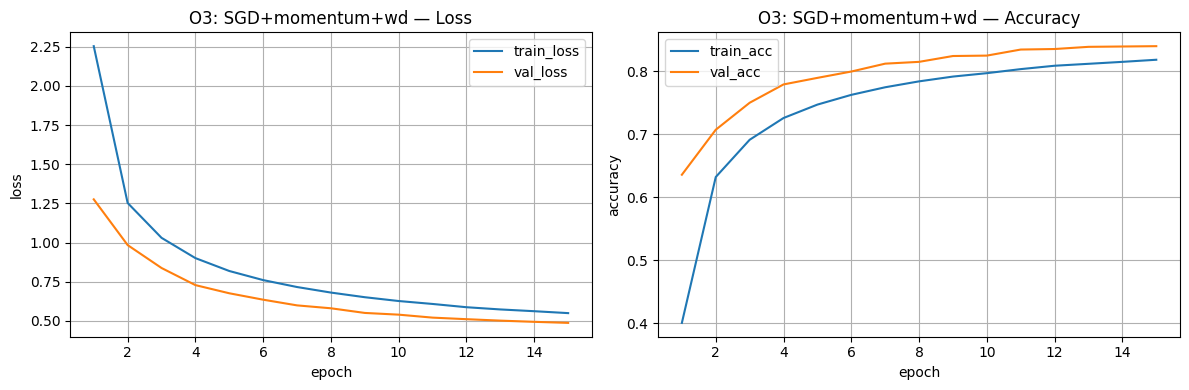

In [18]:
set_seed(SEED)
model_o3 = MLP(
    hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES,
    dropout_p=best_dropout_p, use_batchnorm=best_use_bn,
).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

print("=== O3: SGD(momentum=0.9, weight_decay=1e-4), lr=0.01 ===")
history_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, criterion, device, epochs=15)
plot_history(history_o3, title="O3: SGD+momentum+wd")

all_histories["O3"] = history_o3
all_results["O3"] = {
    "best_val_accuracy": max(history_o3["val_acc"]),
    "best_val_loss": min(history_o3["val_loss"]),
    "epochs_trained": len(history_o3["train_loss"]),
}

### График: диагностика плохого LR (O1 vs O2)

Saved: artifacts/figures/curves_lr_extremes.png


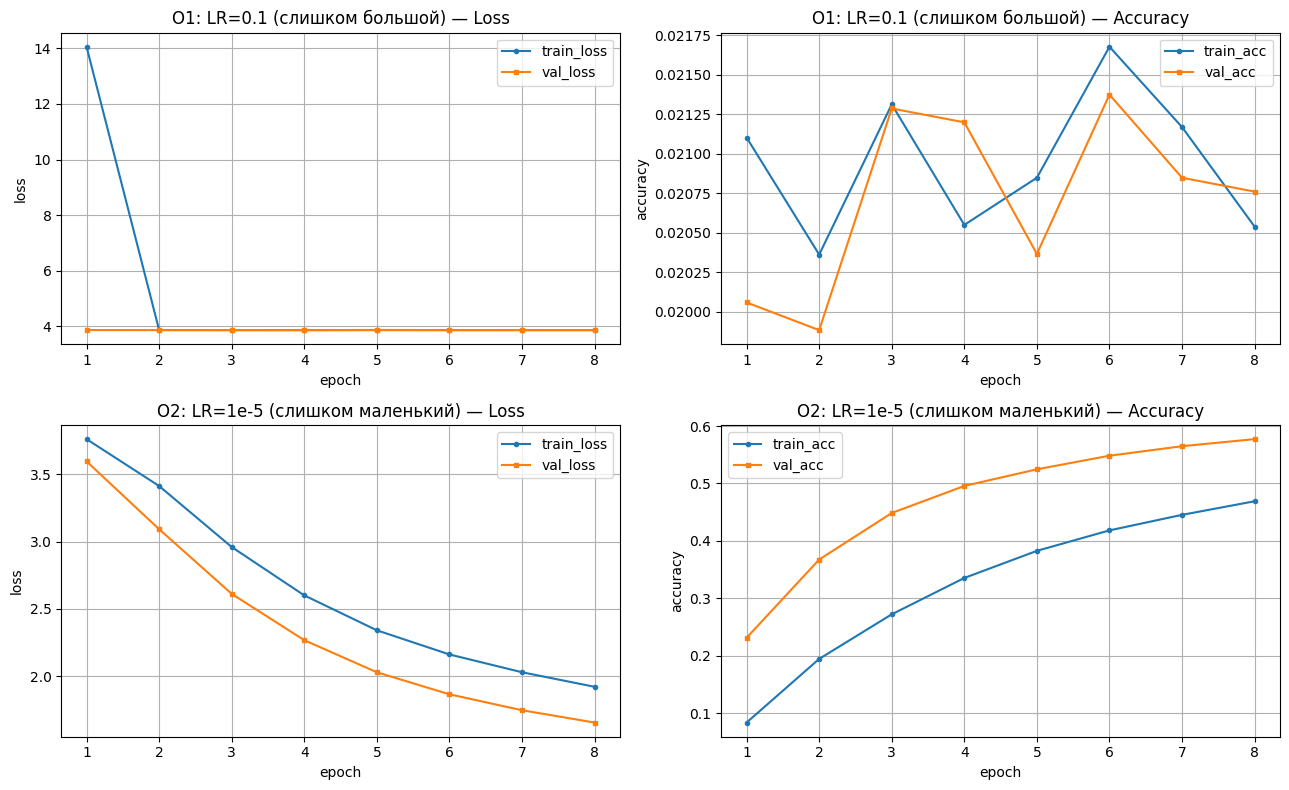

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# O1: LR слишком большой
ep_o1 = np.arange(1, len(history_o1["train_loss"]) + 1)
axes[0, 0].plot(ep_o1, history_o1["train_loss"], label="train_loss", marker="o", markersize=3)
axes[0, 0].plot(ep_o1, history_o1["val_loss"], label="val_loss", marker="s", markersize=3)
axes[0, 0].set_title("O1: LR=0.1 (слишком большой) — Loss")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].set_ylabel("loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(ep_o1, history_o1["train_acc"], label="train_acc", marker="o", markersize=3)
axes[0, 1].plot(ep_o1, history_o1["val_acc"], label="val_acc", marker="s", markersize=3)
axes[0, 1].set_title("O1: LR=0.1 (слишком большой) — Accuracy")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylabel("accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True)

# O2: LR слишком маленький
ep_o2 = np.arange(1, len(history_o2["train_loss"]) + 1)
axes[1, 0].plot(ep_o2, history_o2["train_loss"], label="train_loss", marker="o", markersize=3)
axes[1, 0].plot(ep_o2, history_o2["val_loss"], label="val_loss", marker="s", markersize=3)
axes[1, 0].set_title("O2: LR=1e-5 (слишком маленький) — Loss")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].set_ylabel("loss")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(ep_o2, history_o2["train_acc"], label="train_acc", marker="o", markersize=3)
axes[1, 1].plot(ep_o2, history_o2["val_acc"], label="val_acc", marker="s", markersize=3)
axes[1, 1].set_title("O2: LR=1e-5 (слишком маленький) — Accuracy")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("accuracy")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
fig.savefig("artifacts/figures/curves_lr_extremes.png", dpi=150, bbox_inches="tight")
print("Saved: artifacts/figures/curves_lr_extremes.png")
plt.show()

## 6. Финальная оценка лучшей модели (E4) на test

Test используется **один раз** — только для финальной оценки.

In [20]:
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"=== Финальная оценка E4 на test ===")
print(f"test loss:     {test_loss:.4f}")
print(f"test accuracy: {test_acc:.4f}")

=== Финальная оценка E4 на test ===
test loss:     0.4391
test accuracy: 0.8544


## 7. Сохранение runs.csv

In [21]:
DATASET_NAME = "EMNIST_balanced"

# Формируем таблицу результатов
rows = [
    {
        "experiment_id": "E1",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"MLP{list(HIDDEN_DIMS)}, ReLU, no Dropout, no BN",
        "optimizer": "Adam",
        "lr": LR_BASE,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": all_results["E1"]["epochs_trained"],
        "best_val_accuracy": round(all_results["E1"]["best_val_accuracy"], 4),
        "best_val_loss": round(all_results["E1"]["best_val_loss"], 4),
    },
    {
        "experiment_id": "E2",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"MLP{list(HIDDEN_DIMS)}, ReLU, Dropout(0.3), no BN",
        "optimizer": "Adam",
        "lr": LR_BASE,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": all_results["E2"]["epochs_trained"],
        "best_val_accuracy": round(all_results["E2"]["best_val_accuracy"], 4),
        "best_val_loss": round(all_results["E2"]["best_val_loss"], 4),
    },
    {
        "experiment_id": "E3",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"MLP{list(HIDDEN_DIMS)}, ReLU, no Dropout, BatchNorm",
        "optimizer": "Adam",
        "lr": LR_BASE,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": all_results["E3"]["epochs_trained"],
        "best_val_accuracy": round(all_results["E3"]["best_val_accuracy"], 4),
        "best_val_loss": round(all_results["E3"]["best_val_loss"], 4),
    },
    {
        "experiment_id": "E4",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"MLP{list(HIDDEN_DIMS)}, ReLU, Dropout({best_dropout_p}), BN={best_use_bn}, EarlyStopping(5)",
        "optimizer": "Adam",
        "lr": LR_BASE,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": all_results["E4"]["epochs_trained"],
        "best_val_accuracy": round(all_results["E4"]["best_val_accuracy"], 4),
        "best_val_loss": round(all_results["E4"]["best_val_loss"], 4),
    },
    {
        "experiment_id": "O1",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"MLP{list(HIDDEN_DIMS)}, ReLU, Dropout({best_dropout_p}), BN={best_use_bn}",
        "optimizer": "Adam",
        "lr": 1e-1,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": all_results["O1"]["epochs_trained"],
        "best_val_accuracy": round(all_results["O1"]["best_val_accuracy"], 4),
        "best_val_loss": round(all_results["O1"]["best_val_loss"], 4),
    },
    {
        "experiment_id": "O2",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"MLP{list(HIDDEN_DIMS)}, ReLU, Dropout({best_dropout_p}), BN={best_use_bn}",
        "optimizer": "Adam",
        "lr": 1e-5,
        "momentum": "",
        "weight_decay": 0,
        "epochs_trained": all_results["O2"]["epochs_trained"],
        "best_val_accuracy": round(all_results["O2"]["best_val_accuracy"], 4),
        "best_val_loss": round(all_results["O2"]["best_val_loss"], 4),
    },
    {
        "experiment_id": "O3",
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": f"MLP{list(HIDDEN_DIMS)}, ReLU, Dropout({best_dropout_p}), BN={best_use_bn}",
        "optimizer": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs_trained": all_results["O3"]["epochs_trained"],
        "best_val_accuracy": round(all_results["O3"]["best_val_accuracy"], 4),
        "best_val_loss": round(all_results["O3"]["best_val_loss"], 4),
    },
]

df_runs = pd.DataFrame(rows)
df_runs.to_csv("artifacts/runs.csv", index=False)
print("Saved: artifacts/runs.csv\n")
print(df_runs.to_string(index=False))

Saved: artifacts/runs.csv

experiment_id         dataset  seed                                                 model_summary optimizer      lr momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1 EMNIST_balanced    42                        MLP[512, 256], ReLU, no Dropout, no BN      Adam 0.00100                 0.0000              20             0.8467         0.4690
           E2 EMNIST_balanced    42                      MLP[512, 256], ReLU, Dropout(0.3), no BN      Adam 0.00100                 0.0000              20             0.8524         0.4420
           E3 EMNIST_balanced    42                    MLP[512, 256], ReLU, no Dropout, BatchNorm      Adam 0.00100                 0.0000              20             0.8522         0.4566
           E4 EMNIST_balanced    42 MLP[512, 256], ReLU, Dropout(0.3), BN=False, EarlyStopping(5)      Adam 0.00100                 0.0000              36             0.8582         0.4251
           O1 EMNIST_balance

## 8. Сводка результатов

In [22]:
print("=" * 60)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("=" * 60)
print(f"\nЧасть A (регуляризация):")
for eid in ["E1", "E2", "E3", "E4"]:
    r = all_results[eid]
    print(f"  {eid}: best_val_acc={r['best_val_accuracy']:.4f}, epochs={r['epochs_trained']}")

print(f"\nЛучший из E2/E3: {best_reg}")
print(f"E4 (лучшая модель): best_val_acc={all_results['E4']['best_val_accuracy']:.4f}")
print(f"E4 test_acc: {test_acc:.4f}")

print(f"\nЧасть B (оптимизация):")
for oid in ["O1", "O2", "O3"]:
    r = all_results[oid]
    print(f"  {oid}: best_val_acc={r['best_val_accuracy']:.4f}, epochs={r['epochs_trained']}")

print("\nАртефакты сохранены:")
print("  artifacts/runs.csv")
print("  artifacts/best_model.pt")
print("  artifacts/best_config.json")
print("  artifacts/figures/curves_best.png")
print("  artifacts/figures/curves_lr_extremes.png")

СВОДКА РЕЗУЛЬТАТОВ

Часть A (регуляризация):
  E1: best_val_acc=0.8467, epochs=20
  E2: best_val_acc=0.8524, epochs=20
  E3: best_val_acc=0.8522, epochs=20
  E4: best_val_acc=0.8582, epochs=36

Лучший из E2/E3: E2
E4 (лучшая модель): best_val_acc=0.8582
E4 test_acc: 0.8544

Часть B (оптимизация):
  O1: best_val_acc=0.0214, epochs=8
  O2: best_val_acc=0.5772, epochs=8
  O3: best_val_acc=0.8395, epochs=15

Артефакты сохранены:
  artifacts/runs.csv
  artifacts/best_model.pt
  artifacts/best_config.json
  artifacts/figures/curves_best.png
  artifacts/figures/curves_lr_extremes.png
